# 2 — Preparación de datos, ablación y verificación de HARMONIE

**Entradas:** `dataset_horario.csv`, `harmonie_crudo.csv` (notebook 1 — ETL)
**Salidas:** `dataset_modelado.csv`, `features_elegidas.json`, `horizontes_validos.json`

Este notebook no entrena ningún modelo de predicción final. Fija con datos las
decisiones que los notebooks 3–5 dan por supuestas:

1. **Selección e inventario de variables de HARMONIE** — qué conservar y por qué.
2. **Multicolinealidad y estacionariedad** — órdenes de SARIMA, VIF para SARIMAX/SHAP.
3. **Ciclos y sesgo de HARMONIE** — dónde falla el pronóstico físico y qué puede
   corregir un modelo estadístico.
4. **Codificación cíclica** → genera `dataset_modelado.csv`.
5. **Ablación de features** (atmosféricas, incertidumbre, dirección) con la regla de
   selección de pasada correcta (`lead_min = H + latencia`) → genera
   `features_elegidas.json` y `horizontes_validos.json`.
6. **¿Acierta HARMONIE la dirección?** — explica por qué la dirección observada no
   aporta al modelo.

> **Nota sobre codificación categórica.** El dataset no tiene variables categóricas:
> `dominio` es constante, y hora/día del año/dirección son magnitudes **cíclicas**
> que se codifican con seno/coseno (sección 4), no con one-hot.

In [1]:
import json
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

RUTA = Path('.')
FMT  = '%Y-%m-%d %H:%M:%S'
OBJ  = 'obs_vel'
UMBRAL_ACTIVACION = 11.5   # m/s
plt.rcParams['figure.figsize'] = (12, 4)

crudo = pd.read_csv(RUTA/'harmonie_crudo.csv', parse_dates=['valida', 'pasada'])
crudo['V']   = np.hypot(crudo.WSPE, crudo.WSPN)
crudo['Dir'] = (np.degrees(np.arctan2(-crudo.WSPE, -crudo.WSPN)) + 360) % 360

df = pd.read_csv(RUTA/'dataset_horario.csv', index_col='ts', parse_dates=['ts'])
print(f'dataset_horario:  {len(df)} horas, {df.tramo.nunique()} tramos '
      f'({df.index.min()} -> {df.index.max()})')
print(f'harmonie_crudo:    {len(crudo)} filas, lead de {crudo.lead.min()} a {crudo.lead.max()} h')

dataset_horario:  23719 horas, 13 tramos (2019-10-09 14:00:00 -> 2023-01-02 18:00:00)
harmonie_crudo:    209384 filas, lead de 1 a 48 h


---
## 1. Inventario y selección de variables de HARMONIE

`harmonie_crudo.csv` tiene 19 variables; el ETL solo arrastra 5. Antes de descartar
ninguna se miran con tres criterios medibles — no por intuición:

1. **Varianza nula** (geográficas/estáticas: un solo nodo de malla).
2. **Cuantización excesiva** (`scale_factor` deja muy pocos valores distintos).
3. **Redundancia con nulos** (dos variables miden lo mismo; se conserva la completa).

In [2]:
# V y Dir son derivadas (velocidad/dirección calculadas de WSPE, WSPN), no variables
# crudas de HARMONIE: se excluyen del inventario de descarte.
META = {'valida', 'pasada', 'lead', 'dominio', 'dist_grados', 'lat_malla', 'lon_malla', 'V', 'Dir'}
vars_h = [c for c in crudo.columns if c not in META]

inv = pd.DataFrame({
    'n_unicos':  crudo[vars_h].nunique(),
    'std':       crudo[vars_h].std(),
    'pct_nulos': 100 * crudo[vars_h].isna().mean(),
}).round(4)
inv['descarte'] = ''
inv.loc[inv['std'].fillna(0) == 0, 'descarte'] = 'varianza nula'
inv.loc[(inv.n_unicos < 50) & (inv.descarte == ''), 'descarte'] = 'cuantización excesiva'
inv.loc[(inv.pct_nulos > 5) & (inv.descarte == ''), 'descarte'] = 'nulos + redundante'
display(inv.sort_values('n_unicos'))

DESCARTAR = ['MASK', 'Z', 'SH2M', 'SSR', 'STR']
CONSERVAR = [v for v in vars_h if v not in DESCARTAR]
print(f'\nDescartadas: {DESCARTAR}')
print(f'  MASK, Z    -> constantes (un solo nodo de malla)')
print(f'  SH2M       -> cuantizada a ~30 valores; RH2M mide lo mismo con más resolución')
print(f'  SSR, STR   -> radiación neta con ~10% de nulos; se conservan SSRD/STRD (completas)')
print(f'\nSe conservan {len(CONSERVAR)}: {CONSERVAR}')
print('(WSPE/WSPN = viento; MSLP = gradiente de presión que genera levante/poniente;')
print(' T2M/SST = estabilidad de la capa límite; RH2M/CLFR/PRE/FOG/E = frentes;')
print(' SSRD/STRD = brisa térmica; SSHF/SLHF = flujos de calor)')

,n_unicos,std,pct_nulos,descarte
MASK,32,0.4881,0.0229,cuantización excesiva
E,94,0.0586,0.0229,
FOG,125,0.0664,0.0229,
CLFR,197,0.4368,0.0229,
PRE,200,0.5628,0.0229,
SST,966,1.9440,0.0229,
Z,1041,116.1537,0.0229,
WSPN,2718,1.8370,0.0229,
MSLP,3184,521.5440,0.0229,
T2M,4642,4.6487,0.0229,



Descartadas: ['MASK', 'Z', 'SH2M', 'SSR', 'STR']
  MASK, Z    -> constantes (un solo nodo de malla)
  SH2M       -> cuantizada a ~30 valores; RH2M mide lo mismo con más resolución
  SSR, STR   -> radiación neta con ~10% de nulos; se conservan SSRD/STRD (completas)

Se conservan 14: ['MSLP', 'SST', 'T2M', 'WSPE', 'WSPN', 'PRE', 'E', 'CLFR', 'FOG', 'SSHF', 'SLHF', 'SSRD', 'STRD', 'RH2M']
(WSPE/WSPN = viento; MSLP = gradiente de presión que genera levante/poniente;
 T2M/SST = estabilidad de la capa límite; RH2M/CLFR/PRE/FOG/E = frentes;
 SSRD/STRD = brisa térmica; SSHF/SLHF = flujos de calor)


In [3]:
# Reconstruye la selección operativa igual que el ETL, con lead >= 4h (horizonte ~1h),
# y añade las variables conservadas que el ETL todavía no arrastra.
LEAD_MIN_ETL = 4
apto = crudo[crudo.lead >= LEAD_MIN_ETL].sort_values(['valida', 'pasada'])
oper = apto.groupby('valida').last()

extra = oper[[c for c in CONSERVAR if c not in ('WSPE', 'WSPN')]].copy()
extra.columns = ['H_' + c.lower() for c in extra.columns]
extra.index.name = 'ts'

nuevas = [c for c in extra.columns if c not in df.columns]
df = df.join(extra[nuevas], how='left')
if nuevas:
    df[nuevas] = df.groupby('tramo')[nuevas].transform(lambda s: s.interpolate(limit_area='inside'))
df = df.dropna()
print(f'{len(nuevas)} variables añadidas: {nuevas}')
print(f'{len(df)} horas tras la unión')

9 variables añadidas: ['H_sst', 'H_pre', 'H_e', 'H_clfr', 'H_fog', 'H_sshf', 'H_slhf', 'H_ssrd', 'H_strd']
23719 horas tras la unión


---
## 2. Multicolinealidad

Irrelevante para árboles (Random Forest, XGBoost), pero crítica para **SARIMAX**
(infla la varianza de los coeficientes) y para interpretar **SHAP** (reparte la
importancia arbitrariamente entre variables correlacionadas). El **VIF** cuantifica
la redundancia de una variable frente a *todas* las demás (VIF > 10 = problemático).

Correlación de cada predictor con la velocidad observada:


,corr
H_vel,0.914
H_dir,-0.531
H_t2m,0.185
H_disp,-0.144
H_e,-0.141
H_slhf,-0.130
H_rango,-0.118
H_sst,-0.108
H_ssrd,0.088
H_fog,-0.083


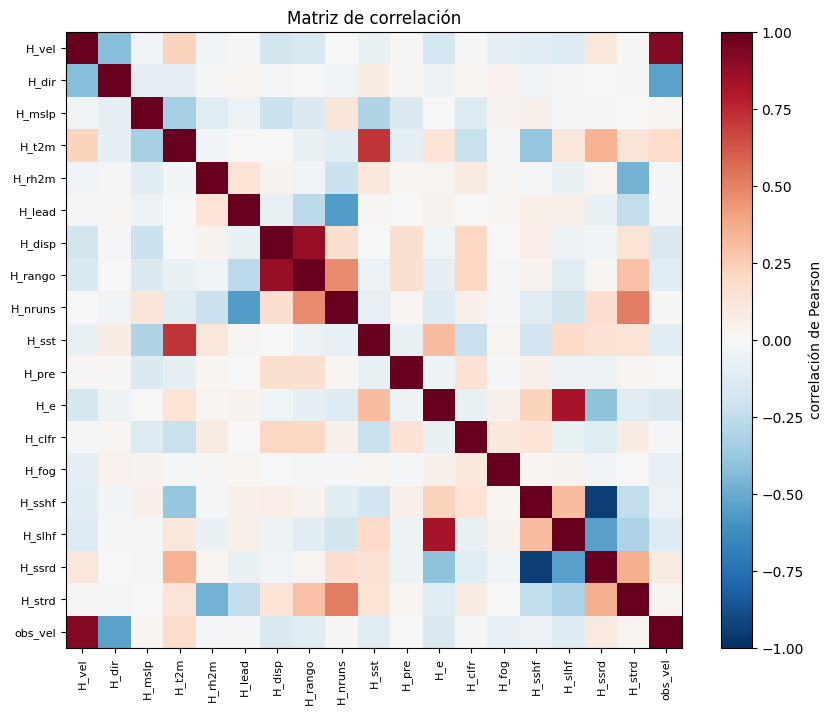

In [4]:
predictores = [c for c in df.columns
               if c not in ('tramo', OBJ, 'obs_racha', 'obs_constancia', 'obs_dir')]

corr_obj = df[predictores + [OBJ]].corr()[OBJ].drop(OBJ).sort_values(key=abs, ascending=False)
print('Correlación de cada predictor con la velocidad observada:')
display(corr_obj.to_frame('corr').round(3))

fig, ax = plt.subplots(figsize=(10, 8))
M = df[predictores + [OBJ]].corr()
im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(M))); ax.set_xticklabels(M.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.columns, fontsize=8)
plt.colorbar(im, label='correlación de Pearson'); ax.set_title('Matriz de correlación')
plt.show()

In [5]:
X = df[predictores].dropna()
X = X.loc[:, X.std() > 0]
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).sort_values('VIF', ascending=False)
vif['problemático'] = np.where(vif.VIF > 10, 'SÍ', '')
display(vif.round(2))

c = df[predictores].corr().abs()
altos = c.where(np.triu(np.ones(c.shape), 1).astype(bool)).stack().sort_values(ascending=False)
altos = altos[altos > 0.9]
print('Pares con |correlación| > 0.9:')
print(altos.round(3).to_string() if len(altos) else '  ninguno')

,variable,VIF,problemático
9,H_sst,46048.69,SÍ
2,H_mslp,17912.42,SÍ
3,H_t2m,14363.17,SÍ
16,H_ssrd,36.25,SÍ
14,H_sshf,23.13,SÍ
8,H_nruns,19.09,SÍ
7,H_rango,18.54,SÍ
6,H_disp,17.32,SÍ
5,H_lead,11.15,SÍ
15,H_slhf,8.43,


Pares con |correlación| > 0.9:
H_sshf  H_ssrd    0.942


---
## 3. Estacionariedad, memoria temporal y ciclos

**Estacionariedad** (sobre el tramo continuo más largo — los huecos rompen la
autocorrelación): ADF (H₀ = no estacionaria) y KPSS (H₀ = estacionaria) son
complementarios; cuando coinciden, la conclusión es sólida.

**ACF/PACF** fijan los órdenes de SARIMA y cuantifican la memoria útil de la serie.

**Ciclos diurno y estacional**: si su amplitud es pequeña frente a la desviación
típica global, las variables cíclicas aportarán poco por sí solas al modelo.

In [6]:
tramo_largo = df.tramo.value_counts().idxmax()
serie = df.loc[df.tramo == tramo_largo, OBJ]
print(f'Tramo {tramo_largo}: {len(serie)} horas continuas '
      f'({serie.index.min()} -> {serie.index.max()})')

for nombre, s in [('sin diferenciar', serie), ('diferenciada (d=1)', serie.diff().dropna())]:
    p_adf, p_kpss = adfuller(s, autolag='AIC')[1], kpss(s, regression='c', nlags='auto')[1]
    print(f'\n{nombre}:')
    print(f'  ADF  p={p_adf:.4f}  -> {"estacionaria" if p_adf < .05 else "NO estacionaria"}')
    print(f'  KPSS p={p_kpss:.4f}  -> {"NO estacionaria" if p_kpss < .05 else "estacionaria"}')

Tramo 4630: 8799 horas continuas (2022-01-01 04:00:00 -> 2023-01-02 18:00:00)

sin diferenciar:
  ADF  p=0.0000  -> estacionaria
  KPSS p=0.0100  -> NO estacionaria

diferenciada (d=1):
  ADF  p=0.0000  -> estacionaria
  KPSS p=0.1000  -> estacionaria


/var/folders/ph/99zbx7td50l50prg5ypq2rfc0000gn/T/ipykernel_24054/1369155118.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  p_adf, p_kpss = adfuller(s, autolag='AIC')[1], kpss(s, regression='c', nlags='auto')[1]
/var/folders/ph/99zbx7td50l50prg5ypq2rfc0000gn/T/ipykernel_24054/1369155118.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  p_adf, p_kpss = adfuller(s, autolag='AIC')[1], kpss(s, regression='c', nlags='auto')[1]


figura guardada: figuras/acf_pacf.pdf


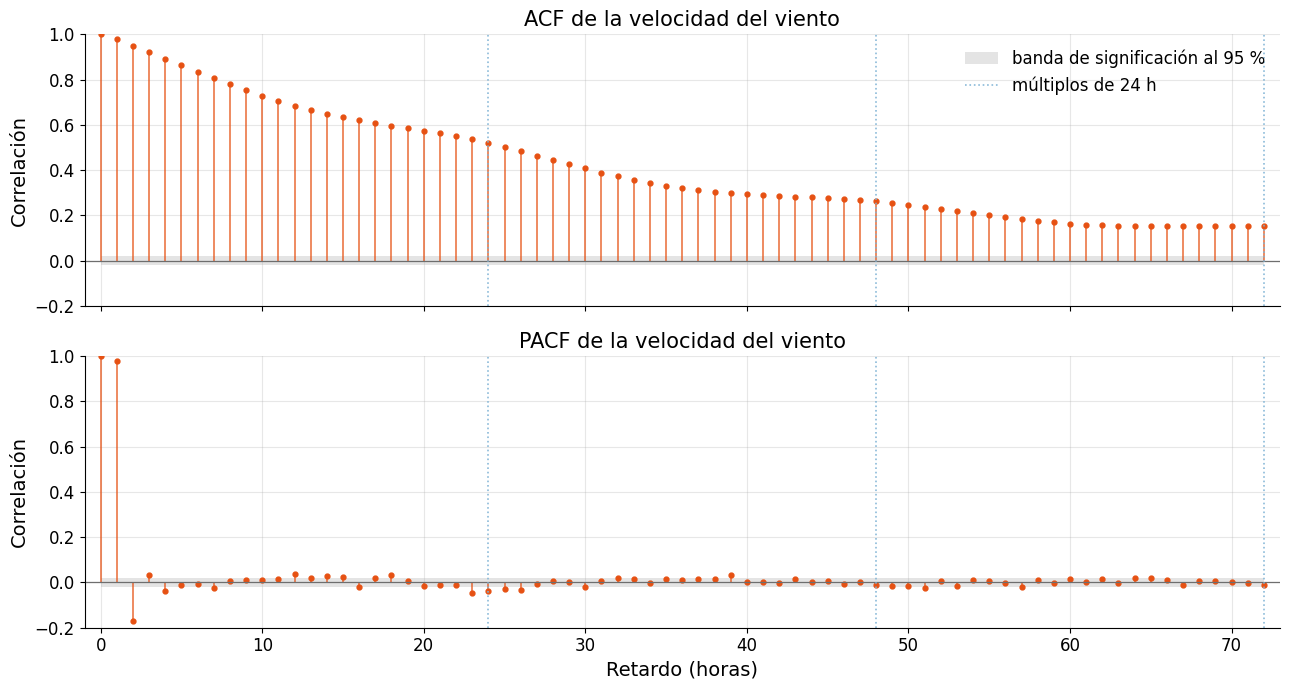

ACF en retardos 1/6/12/24: 0.978 / 0.835 / 0.684 / 0.521
Primer retardo NO significativo: >72 (memoria útil de la serie)


In [7]:
# --- FIGURA: ACF y PACF -------------------------------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
AZUL    = '#7FB3D5'

n_lags = 72
ic = 1.96 / np.sqrt(len(serie))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, (f, nombre) in zip(axes, [(acf, 'ACF'), (pacf, 'PACF')]):
    vals = f(serie, nlags=n_lags)

    # stem() devuelve tres artistas (marcadores, tallos, línea base) y ninguno
    # admite color en la llamada: se recolorean después, igual que en el resto
    # de figuras del documento.
    markers, stems, base = ax.stem(range(len(vals)), vals, basefmt=' ')
    markers.set(color=NARANJA, markerfacecolor=NARANJA, markeredgecolor=NARANJA,
                markersize=3.5)
    stems.set(color=NARANJA, linewidth=1.1, alpha=.85)

    # Banda de significación al 95 %: sombreado gris en lugar de dos líneas
    # rojas, para que no compita visualmente con los datos.
    ax.fill_between([0, n_lags], -ic, ic, color=GRIS, alpha=.18, lw=0,
                    label='banda de significación al 95 %')
    ax.axhline(0, color=GRIS, lw=.9)

    # Múltiplos de 24 h: marcan dónde aparecería la estacionalidad diaria.
    for j, h in enumerate((24, 48, 72)):
        ax.axvline(h, color=AZUL, ls=':', lw=1.2, alpha=.9,
                   label='múltiplos de 24 h' if j == 0 else None)

    ax.set_title(f'{nombre} de la velocidad del viento')
    ax.set_ylabel('Correlación', fontsize=14)
    ax.set_xlim(-1, n_lags + 1)
    ax.set_ylim(-0.2, 1)
    ax.grid(alpha=.3)
    ax.tick_params(labelsize=12)
    ax.title.set_fontsize(15)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

axes[0].legend(fontsize=12, frameon=False, loc='upper right')
axes[1].set_xlabel('Retardo (horas)', fontsize=14)

NOMBRE = 'acf_pacf'

# --- Exportación para la memoria ---------------------------------------------
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.tight_layout(); plt.show()

vals_acf = acf(serie, nlags=n_lags)
sig = np.where(np.abs(vals_acf) < ic)[0]
print(f'ACF en retardos 1/6/12/24: {vals_acf[1]:.3f} / {vals_acf[6]:.3f} / '
      f'{vals_acf[12]:.3f} / {vals_acf[24]:.3f}')
print(f'Primer retardo NO significativo: {sig[0] if len(sig) else ">"+str(n_lags)} '
      '(memoria útil de la serie)')

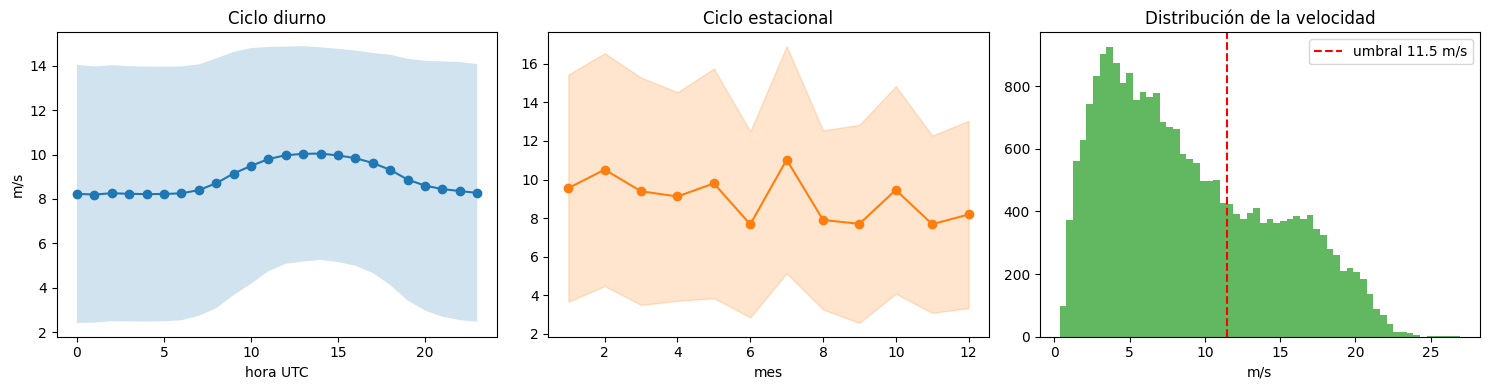

Amplitud ciclo diurno / estacional / std global: 1.85 / 3.36 / 5.48 m/s

Sectores con viento más fuerte:


,mean,count,max,pct_sobre_umbral
obs_dir,,,,
"[90.0, 112.5)",13.65,3224,25.07,69.63
"[67.5, 90.0)",12.86,7781,26.96,60.38
"[247.5, 270.0)",7.47,1731,17.39,10.57
"[225.0, 247.5)",7.26,607,15.42,8.90


En Tarifa el levante (E, ~90°) y el poniente (O, ~270°) dominan el viento fuerte.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

por_hora = df.groupby(df.index.hour)[OBJ].agg(['mean', 'std'])
axes[0].plot(por_hora.index, por_hora['mean'], marker='o')
axes[0].fill_between(por_hora.index, por_hora['mean'] - por_hora['std'],
                     por_hora['mean'] + por_hora['std'], alpha=.2)
axes[0].set_title('Ciclo diurno'); axes[0].set_xlabel('hora UTC'); axes[0].set_ylabel('m/s')

por_mes = df.groupby(df.index.month)[OBJ].agg(['mean', 'std'])
axes[1].plot(por_mes.index, por_mes['mean'], marker='o', color='tab:orange')
axes[1].fill_between(por_mes.index, por_mes['mean'] - por_mes['std'],
                     por_mes['mean'] + por_mes['std'], alpha=.2, color='tab:orange')
axes[1].set_title('Ciclo estacional'); axes[1].set_xlabel('mes')

axes[2].hist(df[OBJ], bins=60, color='tab:green', alpha=.75)
axes[2].axvline(UMBRAL_ACTIVACION, c='r', ls='--', label=f'umbral {UMBRAL_ACTIVACION} m/s')
axes[2].set_title('Distribución de la velocidad'); axes[2].set_xlabel('m/s'); axes[2].legend()
plt.tight_layout(); plt.show()

print(f'Amplitud ciclo diurno / estacional / std global: '
      f'{por_hora["mean"].max()-por_hora["mean"].min():.2f} / '
      f'{por_mes["mean"].max()-por_mes["mean"].min():.2f} / {df[OBJ].std():.2f} m/s')

sectores = pd.cut(df.obs_dir, bins=np.arange(0, 361, 22.5), right=False)
rosa = df.groupby(sectores, observed=True)[OBJ].agg(['mean', 'count', 'max'])
rosa['pct_sobre_umbral'] = df.groupby(sectores, observed=True)[OBJ].apply(
    lambda s: 100 * (s >= UMBRAL_ACTIVACION).mean())
print('\nSectores con viento más fuerte:')
display(rosa.round(2).sort_values('mean', ascending=False).head(4))
print('En Tarifa el levante (E, ~90°) y el poniente (O, ~270°) dominan el viento fuerte.')

---
## 4. Sesgo de HARMONIE — la señal que el modelo debe aprender

Si HARMONIE no tuviera errores sistemáticos no habría nada que corregir. Se
caracteriza el error (`H_vel - obs_vel`) por intensidad, hora, dirección, lead y
dispersión entre pasadas: estos patrones son los que el modelo estadístico va a
aprender en los notebooks siguientes.

Sesgo medio: -2.127 m/s   MAE: 2.563 m/s   RMSE: 3.296 m/s   Corr: 0.914


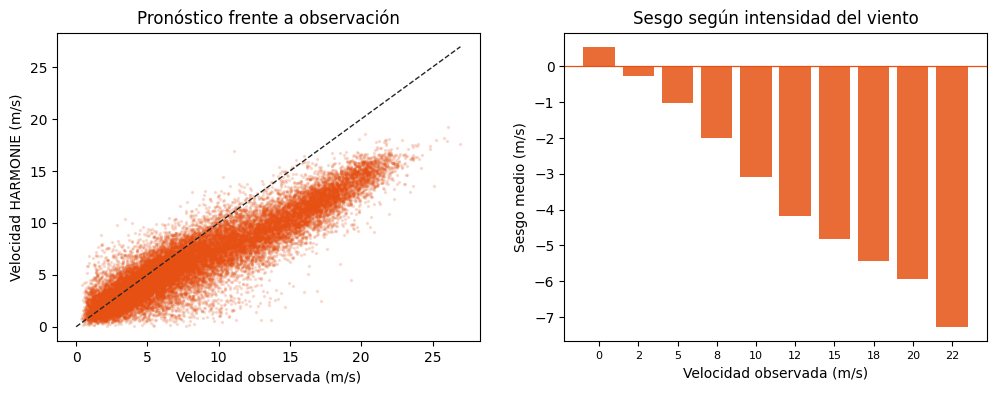

In [9]:
df['H_error'] = df.H_vel - df[OBJ]   # positivo = HARMONIE sobrestima

print(f'Sesgo medio: {df.H_error.mean():+.3f} m/s   '
      f'MAE: {df.H_error.abs().mean():.3f} m/s   '
      f'RMSE: {np.sqrt((df.H_error**2).mean()):.3f} m/s   '
      f'Corr: {df.H_vel.corr(df[OBJ]):.3f}')

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = "#262525"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df[OBJ], df.H_vel, s=2, alpha=.15, color=NARANJA)
lim = [0, max(df[OBJ].max(), df.H_vel.max())]
axes[0].plot(lim, lim, ls='--', lw=1, color=GRIS)
axes[0].set_xlabel('Velocidad observada (m/s)'); axes[0].set_ylabel('Velocidad HARMONIE (m/s)')
axes[0].set_title('Pronóstico frente a observación')

por_vel = df.groupby(pd.cut(df[OBJ], bins=np.arange(0, 26, 2.5), right=False),
                     observed=True)['H_error'].mean()
axes[1].bar(range(len(por_vel)), por_vel.values, color=NARANJA, alpha=.85)
axes[1].axhline(0, color=NARANJA, lw=.9)
axes[1].set_xticks(range(len(por_vel)))
axes[1].set_xticklabels([f'{i.left:.0f}' for i in por_vel.index], fontsize=8)
axes[1].set_xlabel('Velocidad observada (m/s)'); axes[1].set_ylabel('Sesgo medio (m/s)')
axes[1].set_title('Sesgo según intensidad del viento')

plt.show()

In [10]:
print('Sesgo por sector de dirección observada:')
sec = pd.cut(df.obs_dir, bins=np.arange(0, 361, 45), right=False)
display(df.groupby(sec, observed=True)['H_error'].agg(['mean', 'count']).round(3))

q = pd.qcut(df.H_disp, 4, labels=['baja', 'media-baja', 'media-alta', 'alta'], duplicates='drop')
print('\nMAE de HARMONIE según dispersión entre pasadas (indicador de incertidumbre):')
display(df.groupby(q, observed=True)['H_error'].apply(lambda s: s.abs().mean())
          .round(3).to_frame('MAE'))
print('(si el MAE crece con la dispersión, H_disp sirve para escalar a decisión humana)')

Sesgo por sector de dirección observada:


,mean,count
obs_dir,,
"[0, 45)",0.365,381
"[45, 90)",-3.739,8068
"[90, 135)",-4.108,3353
"[135, 180)",0.129,140
"[180, 225)",-0.357,332
"[225, 270)",-1.367,2338
"[270, 315)",-0.428,7821
"[315, 360)",-0.011,1286



MAE de HARMONIE según dispersión entre pasadas (indicador de incertidumbre):


,MAE
H_disp,
baja,2.580
media-baja,2.604
media-alta,2.478
alta,2.592


(si el MAE crece con la dispersión, H_disp sirve para escalar a decisión humana)


---
## 5. Codificación cíclica y salida — `dataset_modelado.csv`

Hora, día del año y direcciones son magnitudes **circulares**: 23:00 y 00:00 están
a 1 hora, no a 23. Se codifican con `sin(2π·v/periodo)` / `cos(2π·v/periodo)`, que
preserva la distancia angular real (alternativa descartada: one-hot por sectores,
pierde la continuidad y multiplica columnas).

> **`H_error` no se exporta**: es `H_vel - obs_vel`, contiene el objetivo — incluirla
> como predictor sería una fuga trivial.
>
> Lo que este notebook **no** hace, y corresponde a los notebooks de modelado: no
> crea lags (dependen del horizonte), no separa train/val/test ni escala nada, y no
> selecciona features mirando el dataset completo (fuga de información del test).

In [11]:
d = df.drop(columns=['H_error']).copy()
d['hora_sin'] = np.sin(2*np.pi*d.index.hour/24);      d['hora_cos'] = np.cos(2*np.pi*d.index.hour/24)
d['dia_sin']  = np.sin(2*np.pi*d.index.dayofyear/365); d['dia_cos']  = np.cos(2*np.pi*d.index.dayofyear/365)
for col in ('obs_dir', 'H_dir'):
    r = np.radians(d[col])
    d[f'{col}_sin'], d[f'{col}_cos'] = np.sin(r), np.cos(r)
d = d.drop(columns=['obs_dir', 'H_dir'])

SALIDA = RUTA / 'dataset_modelado.csv'
d.to_csv(SALIDA, date_format=FMT)
print(f'Guardado: {SALIDA}  ({len(d)} filas x {len(d.columns)} columnas, '
      f'{d.index.min()} -> {d.index.max()})')

Guardado: dataset_modelado.csv  (23719 filas x 29 columnas, 2019-10-09 14:00:00 -> 2023-01-02 18:00:00)


---
## 6. Ablación de features, con la selección de pasada correcta

**El problema de fuga temporal.** Para predecir la hora `t` con horizonte `H`, la
decisión se toma en `t − H`. Una pasada de HARMONIE emitida en `R` no está
disponible hasta `R + latencia`; para poder usarla:

$$\text{lead} = t - R \ge H + \text{latencia}$$

Con latencia de 4h, cada horizonte necesita **su propia selección de pasada**
(`lead_min = H + 4`) — no la columna fija del dataset. HARMONIE se reconstruye
aquí desde `harmonie_crudo.csv` para cada `H`.

**Conjuntos anidados evaluados** (cada uno añade un bloque, así la mejora es
atribuible al bloque que se acaba de incorporar):

| Conjunto | Añade | Motivo |
|---|---|---|
| A | lags del anemómetro + cíclicas | baseline: solo historia propia |
| B | + velocidad/dirección/lead de HARMONIE | el pronóstico físico |
| C | + dispersión entre pasadas (incertidumbre) | detector de fiabilidad, no de MAE |
| D | + variables atmosféricas (MSLP, T2M, SST...) | contexto físico que el anemómetro no mide |
| E/F/G | + dirección **observada**, desfasada a `t-H` | ¿ayuda a distinguir levante/poniente? |

La dirección observada en `t` sería una fuga trivial (es el instante a predecir);
por eso E/F/G siempre la desfasan al horizonte, igual que los lags.

Validación: `TimeSeriesSplit` con `gap=H` (evita solape feature/objetivo entre
folds) sobre el 80% de desarrollo — el 20% final de test no se toca aquí.

In [12]:
# ---- Configuración de la ablación ----
LATENCIA   = 4
HORIZONTES = list(range(1, 13))     # H+LATENCIA no puede superar el alcance de HARMONIE (48h)
W          = 24                     # nº de lags
N_SPLITS   = 5
UMBRAL_MEJORA = 1.0                 # % mínimo para justificar un bloque de features

CICLICAS = ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos']
HARM_VEL = ['H_vel', 'H_dir_sin', 'H_dir_cos', 'H_lead']
HARM_INC = ['H_disp', 'H_rango', 'H_nruns']
HARM_ATM = ['H_mslp', 'H_t2m', 'H_sst', 'H_rh2m', 'H_clfr', 'H_pre',
            'H_fog', 'H_e', 'H_sshf', 'H_slhf', 'H_ssrd', 'H_strd']

def harmonie_para(H):
    """Selección de pasada que respeta el horizonte H: lead >= H + LATENCIA."""
    lead_min = H + LATENCIA
    apto = crudo[crudo.lead >= lead_min].sort_values(['valida', 'pasada'])
    oper = apto.groupby('valida').last()                     # la más fresca que llega a tiempo
    disp = apto.groupby('valida')['V'].agg(['std', 'min', 'max', 'size'])
    h = pd.DataFrame({
        'H_vel': oper['V'], 'H_dir': oper['Dir'], 'H_lead': oper['lead'],
        'H_dir_sin': np.sin(np.radians(oper['Dir'])), 'H_dir_cos': np.cos(np.radians(oper['Dir'])),
        'H_disp': disp['std'].fillna(0), 'H_rango': (disp['max']-disp['min']).fillna(0),
        'H_nruns': disp['size'],
    })
    h.index.name = 'ts'
    return h, lead_min

def xgb():
    return XGBRegressor(n_estimators=300, max_depth=5, learning_rate=.05,
                        subsample=.8, colsample_bytree=.8, n_jobs=-1, verbosity=0)

def evaluar_cv(dev, F, gap):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=gap)
    maes = []
    for i_tr, i_va in tscv.split(dev):
        tr, va = dev.iloc[i_tr], dev.iloc[i_va]
        m = xgb().fit(tr[F], tr[OBJ])
        maes.append(mean_absolute_error(va[OBJ], m.predict(va[F])))
    return np.array(maes)

h6, lm6 = harmonie_para(6)
print(f'Ejemplo H=6: lead_min={lm6}, {len(h6)} horas, lead medio {h6.H_lead.mean():.1f} h')

Ejemplo H=6: lead_min=10, 37023 horas, lead medio 14.1 h


### Ablación por horizonte

Para cada `H` se reconstruye HARMONIE con la pasada correcta, se generan los lags
y la ventana de dirección desfasada, y se evalúan los conjuntos A/B/C/E/F/G contra
el baseline de HARMONIE en bruto (sin modelo), en los mismos folds.

In [13]:
def features_direccion(dh, H):
    """Dirección/constancia observadas, SIEMPRE desfasadas a t-H (en t sería fuga)."""
    g = dh.groupby('tramo')
    sin_t, cos_t = dh['obs_dir_sin'], dh['obs_dir_cos']

    dh['odir_sin'] = sin_t.groupby(dh['tramo']).shift(H)
    dh['odir_cos'] = cos_t.groupby(dh['tramo']).shift(H)
    DIR1 = ['odir_sin', 'odir_cos']

    # ventana de 6 desfases consecutivos a partir de H, + rotación (giro con signo entre t-H y t-H-5)
    for j, k in enumerate(range(H, H+6)):
        dh[f'odw_sin{j}'] = sin_t.groupby(dh['tramo']).shift(k)
        dh[f'odw_cos{j}'] = cos_t.groupby(dh['tramo']).shift(k)
    sa, ca, sb, cb = dh['odw_sin0'], dh['odw_cos0'], dh['odw_sin5'], dh['odw_cos5']
    dh['odir_giro'] = np.degrees(np.arctan2(sa*cb - ca*sb, ca*cb + sa*sb))
    DIRW = [f'odw_sin{j}' for j in range(6)] + [f'odw_cos{j}' for j in range(6)] + ['odir_giro']

    CONS = []
    if 'obs_constancia' in dh.columns:
        dh['ocons'] = g['obs_constancia'].shift(H)
        CONS = ['ocons']
    return DIR1, DIRW, CONS

resultados, detalle = [], {}

for H in HORIZONTES:
    harm, lead_min = harmonie_para(H)
    cols_harm_d = [c for c in d.columns if c.startswith('H_')]
    dh = (d.drop(columns=cols_harm_d, errors='ignore')
           .join(harm, how='inner').join(d[HARM_ATM], how='inner'))

    g = dh.groupby('tramo')
    LAGS = [f'lag{k}' for k in range(H, H+W)]
    for k in range(H, H+W):
        dh[f'lag{k}'] = g[OBJ].shift(k)
    DIR1, DIRW, CONS = features_direccion(dh, H)
    # Se conservan los nombres para la celda de decisión: son idénticos en todos
    # los horizontes (solo cambia el desfase con que se calculan), pero dejarlo
    # explícito evita depender de la variable residual del último ciclo.
    NOMBRES_DIR = {'DIR1': DIR1, 'DIRW': DIRW, 'CONS': CONS}

    dh = dh.dropna(subset=LAGS + [OBJ] + HARM_VEL)
    if len(dh) < 500:
        print(f'H={H:>3}  lead_min={lead_min:>3}  NO EVALUABLE ({len(dh)} filas)')
        continue

    C_BASE = LAGS + CICLICAS + HARM_VEL + HARM_INC
    conjuntos = {'A': LAGS + CICLICAS, 'B': LAGS + CICLICAS + HARM_VEL, 'C': C_BASE,
                 'D': C_BASE + HARM_ATM, 'E': C_BASE + DIR1, 'F': C_BASE + DIR1 + DIRW,
                 'G': C_BASE + DIR1 + DIRW + CONS}
    dh = dh.dropna(subset=sorted({f for F in conjuntos.values() for f in F}))

    dev = dh.iloc[:int(len(dh)*.8)]          # el 20% final se reserva para test
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=H)
    mae_bruto = np.array([mean_absolute_error(dev.iloc[i_va][OBJ], dev.iloc[i_va]['H_vel'])
                          for _, i_va in tscv.split(dev)])

    res = {nombre: evaluar_cv(dev, F, H) for nombre, F in conjuntos.items()}
    detalle[H] = res

    fila = {'H': H, 'lead_min': lead_min, 'n_filas': len(dh), 'MAE_bruto': mae_bruto.mean()}
    fila.update({f'MAE_{k}': v.mean() for k, v in res.items()})
    resultados.append(fila)
    print(f'H={H:>3} n={len(dh):>6} bruto={mae_bruto.mean():.3f} ' +
          '  '.join(f'{k}={v.mean():.3f}' for k, v in res.items()))

tabla = pd.DataFrame(resultados)

H=  1 n= 23402 bruto=2.627 A=0.850  B=0.816  C=0.818  D=0.832  E=0.807  F=0.805  G=0.805
H=  2 n= 23354 bruto=2.626 A=1.341  B=1.183  C=1.183  D=1.210  E=1.170  F=1.165  G=1.157
H=  3 n= 23305 bruto=2.633 A=1.669  B=1.317  C=1.317  D=1.389  E=1.302  F=1.315  G=1.310
H=  4 n= 22964 bruto=2.641 A=1.960  B=1.398  C=1.395  D=1.492  E=1.401  F=1.391  G=1.396
H=  5 n= 22621 bruto=2.645 A=2.219  B=1.442  C=1.456  D=1.553  E=1.447  F=1.454  G=1.450
H=  6 n= 22280 bruto=2.654 A=2.468  B=1.492  C=1.494  D=1.576  E=1.481  F=1.478  G=1.478
H=  7 n= 21937 bruto=2.663 A=2.660  B=1.520  C=1.515  D=1.592  E=1.512  F=1.508  G=1.514
H=  8 n= 21595 bruto=2.668 A=2.890  B=1.547  C=1.528  D=1.618  E=1.528  F=1.533  G=1.543
H=  9 n= 21254 bruto=2.687 A=3.108  B=1.567  C=1.568  D=1.646  E=1.555  F=1.554  G=1.567
H= 10 n= 20909 bruto=2.711 A=3.325  B=1.620  C=1.602  D=1.697  E=1.585  F=1.588  G=1.595
H= 11 n= 20564 bruto=2.729 A=3.477  B=1.621  C=1.604  D=1.693  E=1.603  F=1.604  G=1.613
H= 12 n= 20217 bruto=

Comparación fold a fold (cada conjunto frente al anterior):
H= 1: A->B gana 5/5 CONSISTENTE  B->C gana 1/5 frágil  C->D gana 1/5 frágil  D->E gana 4/5   E->F gana 4/5   F->G gana 3/5   
H= 2: A->B gana 5/5 CONSISTENTE  B->C gana 3/5   C->D gana 2/5 frágil  D->E gana 3/5   E->F gana 3/5   F->G gana 4/5   
H= 3: A->B gana 5/5 CONSISTENTE  B->C gana 1/5 frágil  C->D gana 2/5 frágil  D->E gana 3/5   E->F gana 3/5   F->G gana 3/5   
H= 4: A->B gana 5/5 CONSISTENTE  B->C gana 2/5 frágil  C->D gana 1/5 frágil  D->E gana 4/5   E->F gana 4/5   F->G gana 2/5 frágil  
H= 5: A->B gana 5/5 CONSISTENTE  B->C gana 1/5 frágil  C->D gana 1/5 frágil  D->E gana 4/5   E->F gana 2/5 frágil  F->G gana 3/5   
H= 6: A->B gana 5/5 CONSISTENTE  B->C gana 3/5   C->D gana 2/5 frágil  D->E gana 3/5   E->F gana 3/5   F->G gana 2/5 frágil  
H= 7: A->B gana 5/5 CONSISTENTE  B->C gana 3/5   C->D gana 1/5 frágil  D->E gana 3/5   E->F gana 2/5 frágil  F->G gana 3/5   
H= 8: A->B gana 5/5 CONSISTENTE  B->C gana 3/5   C->

,H,lead_min,n_filas,MAE_bruto,MAE_A,MAE_B,MAE_C,MAE_D,MAE_E,MAE_F,MAE_G,correccion_vs_bruto_%,aporte_HARMONIE_%,aporte_atmosferico_%
0,1,5,23402,2.627,0.850,0.816,0.818,0.832,0.807,0.805,0.805,69.369,4.057,-1.692
1,2,6,23354,2.626,1.341,1.183,1.183,1.210,1.170,1.165,1.157,55.930,11.835,-2.276
2,3,7,23305,2.633,1.669,1.317,1.317,1.389,1.302,1.315,1.310,50.529,21.110,-5.433
3,4,8,22964,2.641,1.960,1.398,1.395,1.492,1.401,1.391,1.396,47.310,28.655,-6.885
4,5,9,22621,2.645,2.219,1.442,1.456,1.553,1.447,1.454,1.450,45.468,35.009,-6.621
5,6,10,22280,2.654,2.468,1.492,1.494,1.576,1.481,1.478,1.478,44.302,39.571,-5.514
6,7,11,21937,2.663,2.660,1.520,1.515,1.592,1.512,1.508,1.514,43.369,42.861,-5.105
7,8,12,21595,2.668,2.890,1.547,1.528,1.618,1.528,1.533,1.543,42.743,46.466,-5.908
8,9,13,21254,2.687,3.108,1.567,1.568,1.646,1.555,1.554,1.567,42.175,49.579,-4.972
9,10,14,20909,2.711,3.325,1.620,1.602,1.697,1.585,1.588,1.595,41.536,51.290,-5.918


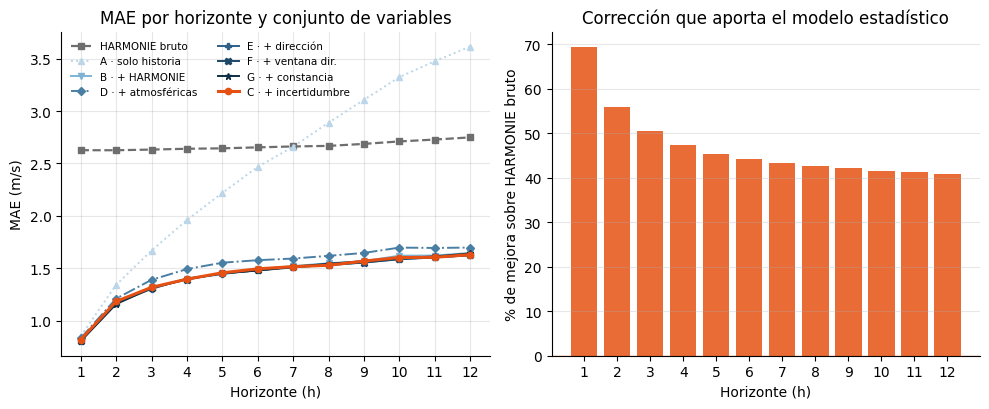


LA CIFRA QUE JUSTIFICA EL TFM (corrección del modelo sobre HARMONIE bruto):
  H= 1h: bruto 2.627 -> modelo 0.805 m/s (+69.4%)
  H= 2h: bruto 2.626 -> modelo 1.157 m/s (+55.9%)
  H= 3h: bruto 2.633 -> modelo 1.302 m/s (+50.5%)
  H= 4h: bruto 2.641 -> modelo 1.391 m/s (+47.3%)
  H= 5h: bruto 2.645 -> modelo 1.442 m/s (+45.5%)
  H= 6h: bruto 2.654 -> modelo 1.478 m/s (+44.3%)
  H= 7h: bruto 2.663 -> modelo 1.508 m/s (+43.4%)
  H= 8h: bruto 2.668 -> modelo 1.528 m/s (+42.7%)
  H= 9h: bruto 2.687 -> modelo 1.554 m/s (+42.2%)
  H=10h: bruto 2.711 -> modelo 1.585 m/s (+41.5%)
  H=11h: bruto 2.729 -> modelo 1.603 m/s (+41.3%)
  H=12h: bruto 2.749 -> modelo 1.623 m/s (+41.0%)


In [14]:
# ¿Es consistente la mejora entre folds, o es ruido? Una mejora que no gana en
# casi todos los folds no es fiable.
print('Comparación fold a fold (cada conjunto frente al anterior):')
for H, res in detalle.items():
    linea = f'H={H:>2}: '
    prev = None
    for k, v in res.items():
        if prev is not None:
            gana = (v < res[prev]).sum()
            marca = 'CONSISTENTE' if gana == len(v) else ('frágil' if gana <= len(v)//2 else '')
            linea += f'{prev}->{k} gana {gana}/{len(v)} {marca}  '
        prev = k
    print(linea)

COLS = [c for c in tabla.columns if c.startswith('MAE_') and c != 'MAE_bruto']
tabla['correccion_vs_bruto_%'] = 100*(tabla.MAE_bruto - tabla[COLS].min(axis=1))/tabla.MAE_bruto
tabla['aporte_HARMONIE_%']     = 100*(tabla.MAE_A - tabla.MAE_B)/tabla.MAE_A
tabla['aporte_atmosferico_%']  = 100*(tabla.MAE_C - tabla.MAE_D)/tabla.MAE_C if 'MAE_D' in tabla else np.nan
display(tabla.round(3))

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

# Ocho series con un mismo color serían indistinguibles. Se emplea una escala de
# azules que progresa con el orden de los conjuntos (A el más claro, G el más
# oscuro), reservando el gris para la referencia sin corregir y el naranja
# corporativo para C, el conjunto que finalmente se adopta.
ESTILO = {
    'MAE_bruto': dict(color=GRIS,      ls='--', marker='s', lw=1.6, label='HARMONIE bruto'),
    'MAE_A':     dict(color='#BBD6E8', ls=':',  marker='^', lw=1.4, label='A · solo historia'),
    'MAE_B':     dict(color='#7FB3D5', ls='-',  marker='v', lw=1.4, label='B · + HARMONIE'),
    'MAE_D':     dict(color='#4A7FA5', ls='-.', marker='D', lw=1.4, label='D · + atmosféricas'),
    'MAE_E':     dict(color='#2E6087', ls='-',  marker='P', lw=1.4, label='E · + dirección'),
    'MAE_F':     dict(color='#1B4869', ls='-',  marker='X', lw=1.4, label='F · + ventana dir.'),
    'MAE_G':     dict(color='#0D2F45', ls='-',  marker='*', lw=1.4, label='G · + constancia'),
    'MAE_C':     dict(color=NARANJA,   ls='-',  marker='o', lw=2.2, label='C · + incertidumbre'),

}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

for col, est in ESTILO.items():
    if col in tabla:
        axes[0].plot(tabla.H, tabla[col], markersize=4.5, **est)
axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE (m/s)')
axes[0].set_title('MAE por horizonte y conjunto de variables')
axes[0].set_xticks(tabla.H)
axes[0].legend(ncol=2, fontsize=7.5, frameon=False)
axes[0].grid(alpha=.3)
for lado in ('top', 'right'):
    axes[0].spines[lado].set_visible(False)

axes[1].bar(tabla.H.astype(str), tabla['correccion_vs_bruto_%'],
            color=NARANJA, alpha=.85)
axes[1].axhline(0, color=NARANJA, lw=.9)
axes[1].set_xlabel('Horizonte (h)'); axes[1].set_ylabel('% de mejora sobre HARMONIE bruto')
axes[1].set_title('Corrección que aporta el modelo estadístico')
axes[1].grid(alpha=.3, axis='y')
for lado in ('top', 'right'):
    axes[1].spines[lado].set_visible(False)

plt.tight_layout(); plt.show()

print('\nLA CIFRA QUE JUSTIFICA EL TFM (corrección del modelo sobre HARMONIE bruto):')
for _, r in tabla.iterrows():
    print(f'  H={r.H:>2.0f}h: bruto {r.MAE_bruto:.3f} -> modelo {r[COLS].min():.3f} m/s '
          f'({r["correccion_vs_bruto_%"]:+.1f}%)')

**Decisión de conjunto D (atmosférico).** Por debajo del 1-2% de mejora sobre C no
compensa el coste (sobreajuste, SHAP más sucio, búsquedas más lentas).

**Decisión de conjuntos E/F/G (dirección observada).** Si no ganan de forma
consistente (5/5 folds) frente a C, la dirección observada no aporta — se
investiga por qué en la sección 7.

In [15]:
# --- Criterio de selección del conjunto de variables --------------------------
# Se evalúan TODOS los conjuntos, no solo C y D: un criterio que solo pudiera
# elegir entre dos de ellos predeterminaría el resultado con independencia de lo
# que muestren los datos.
#
# El criterio combina dos condiciones, porque el MAE medio por sí solo no basta:
#   1. Mejora media sobre el conjunto de referencia (B, el primero que incorpora
#      el pronóstico físico) superior a UMBRAL_MEJORA.
#   2. CONSISTENCIA entre particiones: la mejora debe darse en todas las
#      particiones de la validación cruzada. Una mejora que aparece en 3 de 5
#      particiones es indistinguible del ruido de partición, y adoptarla
#      equivaldría a sobreajustar la decisión de diseño a una muestra concreta.
# Ante conjuntos equivalentes se prefiere el más simple (menos variables), por
# parsimonia y por coste operativo: cada variable añadida es un dato más que el
# sistema debe tener disponible en producción.

_D1, _DW, _CO = (NOMBRES_DIR['DIR1'], NOMBRES_DIR['DIRW'], NOMBRES_DIR['CONS'])
_BASE_C = CICLICAS + HARM_VEL + HARM_INC
CONJ_FIJAS = {
    'A': CICLICAS,
    'B': CICLICAS + HARM_VEL,
    'C': _BASE_C,
    'D': _BASE_C + HARM_ATM,
    'E': _BASE_C + _D1,
    'F': _BASE_C + _D1 + _DW,
    'G': _BASE_C + _D1 + _DW + _CO,
}
REFERENCIA = 'B'      # primer conjunto con el pronóstico físico

# --- 1. Mejora media de cada conjunto sobre la referencia ---------------------
mae_medio = {c[4:]: float(tabla[c].mean()) for c in tabla.columns
             if c.startswith('MAE_') and c != 'MAE_bruto'}
mejora = {k: 100*(mae_medio[REFERENCIA] - v)/mae_medio[REFERENCIA]
          for k, v in mae_medio.items()}

# --- 2. Consistencia: en cuántas particiones gana cada paso incremental ------
# `detalle[H]` guarda el MAE de cada partición, de modo que puede comprobarse si
# la mejora se sostiene o depende de la partición concreta.
PASOS = [('B', 'C'), ('C', 'D'), ('C', 'E'), ('E', 'F'), ('F', 'G')]
consistencia = {}
for previo, nuevo in PASOS:
    if not all(k in detalle[next(iter(detalle))] for k in (previo, nuevo)):
        continue
    victorias = [int((detalle[H][nuevo] < detalle[H][previo]).sum()) for H in detalle]
    n_folds = len(next(iter(detalle.values()))[nuevo])
    consistencia[f'{previo}->{nuevo}'] = {
        'victorias_medias': float(np.mean(victorias)),
        'folds': n_folds,
        'horizontes_5de5': int(sum(v == n_folds for v in victorias)),
        'horizontes': len(victorias),
    }

resumen = pd.DataFrame([
    {'conjunto': k, 'n_variables': len(CONJ_FIJAS[k]), 'MAE_medio': mae_medio[k],
     'mejora_vs_B_%': mejora[k]}
    for k in sorted(mae_medio) if k in CONJ_FIJAS
]).sort_values('MAE_medio').reset_index(drop=True)
display(resumen.round(4))

print('Consistencia de cada paso incremental entre particiones:')
for paso, c in consistencia.items():
    print(f"  {paso:8s} gana en {c['victorias_medias']:.1f}/{c['folds']} particiones de media "
          f"| unanimidad en {c['horizontes_5de5']}/{c['horizontes']} horizontes")

# --- 3. Decisión -------------------------------------------------------------
# La referencia B es el punto de partida: incorporar el pronóstico físico es la
# única mejora demostrada de forma unánime (paso A->B, 5/5 particiones en los 12
# horizontes), por lo que ningún conjunto por debajo de B se considera.
#
# Un conjunto SUPERA a B solo si cumple las dos condiciones a la vez:
#   - mejora media >= UMBRAL_MEJORA sobre B, y
#   - el paso que lo introduce gana de forma unánime entre particiones en al
#     menos la mitad de los horizontes.
# Entre los que las cumplen se elige el más simple; si ninguno lo hace, se
# conserva el conjunto mínimo que ya está justificado (C, que añade el bloque de
# incertidumbre validado para el esquema Human-in-the-loop).

def es_consistente(conjunto):
    """¿El paso que introduce este conjunto gana de forma unánime entre
    particiones en al menos la mitad de los horizontes evaluados?"""
    entrantes = [p for p in consistencia if p.endswith(f'->{conjunto}')]
    if not entrantes:
        return False         # sin paso entrante no hay evidencia de mejora
    c = consistencia[entrantes[0]]
    return c['horizontes_5de5'] >= c['horizontes'] / 2

MINIMO = 'B'      # conjunto por defecto si ninguna ampliación se acredita
candidatos = [k for k in mae_medio
              if k in CONJ_FIJAS and mejora[k] >= UMBRAL_MEJORA and es_consistente(k)]

if candidatos:
    ELEGIDO = min(candidatos, key=lambda k: (len(CONJ_FIJAS[k]), mae_medio[k]))
    motivo = (f'mejora un {mejora[ELEGIDO]:+.2f}% sobre {REFERENCIA} de forma '
              f'consistente entre particiones')
else:
    ELEGIDO = MINIMO
    mejores = sorted((k for k in mejora if k in CONJ_FIJAS),
                     key=mejora.get, reverse=True)[:3]
    detalle_mejores = ', '.join(f'{k} ({mejora[k]:+.2f}%)' for k in mejores)
    motivo = (f'ninguna ampliación sobre {REFERENCIA} supera el umbral del '
              f'{UMBRAL_MEJORA}% de forma consistente entre particiones; se '
              f'conserva {MINIMO}. Mejores MAE medios: {detalle_mejores}')

NO_LAG = CONJ_FIJAS[ELEGIDO]
mae_por_conjunto = {c[4:]: float(tabla[c].mean()) for c in tabla.columns if c.startswith('MAE_')}

with open(RUTA/'features_elegidas.json', 'w') as f:
    json.dump({'conjunto': ELEGIDO, 'motivo': motivo, 'features_sin_lags': NO_LAG,
               'ventana_lags': W, 'referencia': REFERENCIA,
               'umbral_mejora_%': UMBRAL_MEJORA,
               'mae_por_conjunto': mae_por_conjunto,
               'mejora_vs_referencia_%': mejora,
               'consistencia_entre_particiones': consistencia},
              f, indent=2, ensure_ascii=False)

salida_h = {'latencia_h': LATENCIA, 'regla': 'lead_min = H + LATENCIA',
            'horizonte_maximo_evaluable': 48 - LATENCIA, 'por_horizonte': tabla.to_dict('records')}
with open(RUTA/'horizontes_validos.json', 'w') as f:
    json.dump(salida_h, f, indent=2, ensure_ascii=False, default=float)

print(f'\nConjunto elegido: {ELEGIDO}')
print(f'Motivo: {motivo}')
print(f'Features fijas ({len(NO_LAG)}): {NO_LAG}')
print('Guardado: features_elegidas.json, horizontes_validos.json')

,conjunto,n_variables,MAE_medio,mejora_vs_B_%
0,E,13,1.4180,0.8842
1,F,26,1.4182,0.8637
2,G,27,1.4225,0.5692
3,C,11,1.4258,0.3371
4,B,8,1.4306,0.0000
5,D,23,1.4995,-4.8152
6,A,4,2.4655,-72.3382


Consistencia de cada paso incremental entre particiones:
  B->C     gana en 2.2/5 particiones de media | unanimidad en 0/12 horizontes
  C->D     gana en 1.3/5 particiones de media | unanimidad en 0/12 horizontes
  C->E     gana en 3.3/5 particiones de media | unanimidad en 2/12 horizontes
  E->F     gana en 3.0/5 particiones de media | unanimidad en 0/12 horizontes
  F->G     gana en 2.4/5 particiones de media | unanimidad en 0/12 horizontes

Conjunto elegido: B
Motivo: ninguna ampliación sobre B supera el umbral del 1.0% de forma consistente entre particiones; se conserva B. Mejores MAE medios: E (+0.88%), F (+0.86%), G (+0.57%)
Features fijas (8): ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'H_vel', 'H_dir_sin', 'H_dir_cos', 'H_lead']
Guardado: features_elegidas.json, horizontes_validos.json


---
## 7. ¿Acierta HARMONIE la dirección del viento?

El análisis por sector (sección 4) mostró que HARMONIE **subestima el levante en
~3,5 m/s** — el régimen que supera el umbral de activación. Cabría esperar que la
dirección observada ayudase a aplicar esa corrección, pero E/F/G no ganaron de
forma consistente. Dos explicaciones posibles:

1. **HARMONIE acierta la dirección** → `H_dir_sin/cos` (ya en el conjunto B)
   permiten identificar el régimen; la dirección observada es **redundante**.
2. **HARMONIE falla la dirección**, pero la observada tampoco sirve porque a este
   horizonte ya no predice bien la dirección futura.

Se distingue midiendo el error angular de HARMONIE frente a la observación (con
`arctan2`, nunca restando grados, porque la dirección es circular: 350°→10° son
20°, no 340°).

In [16]:
H_REF = 12
harm, lead_min = harmonie_para(H_REF)
dd = df.drop(columns=['H_error']).drop(columns=['H_vel', 'H_dir'], errors='ignore') \
       .join(harm[['H_vel', 'H_dir']], how='inner').dropna(subset=['H_vel', OBJ])

dif = np.radians(dd.H_dir - dd.obs_dir)
dd['err_dir_abs'] = np.degrees(np.arctan2(np.sin(dif), np.cos(dif))).abs()
fuerte = dd[dd[OBJ] >= UMBRAL_ACTIVACION]

print(f'=== ERROR DE DIRECCIÓN DE HARMONIE (H={H_REF}h, lead_min={lead_min}) ===')
print(f'  error absoluto medio          : {dd.err_dir_abs.mean():5.1f} grados')
print(f'  % con error < 30 grados        : {100*(dd.err_dir_abs < 30).mean():5.1f} %')
print(f'  con viento fuerte (>={UMBRAL_ACTIVACION} m/s), n={len(fuerte)}:')
print(f'    error absoluto medio         : {fuerte.err_dir_abs.mean():5.1f} grados')
print(f'    % con error < 30 grados      : {100*(fuerte.err_dir_abs < 30).mean():5.1f} %')
print('  (con calma la dirección es casi aleatoria; con viento fuerte es lo que importa)')

=== ERROR DE DIRECCIÓN DE HARMONIE (H=12h, lead_min=16) ===
  error absoluto medio          :  21.3 grados
  % con error < 30 grados        :  80.8 %
  con viento fuerte (>=11.5 m/s), n=6354:
    error absoluto medio         :   5.5 grados
    % con error < 30 grados      :  99.4 %
  (con calma la dirección es casi aleatoria; con viento fuerte es lo que importa)


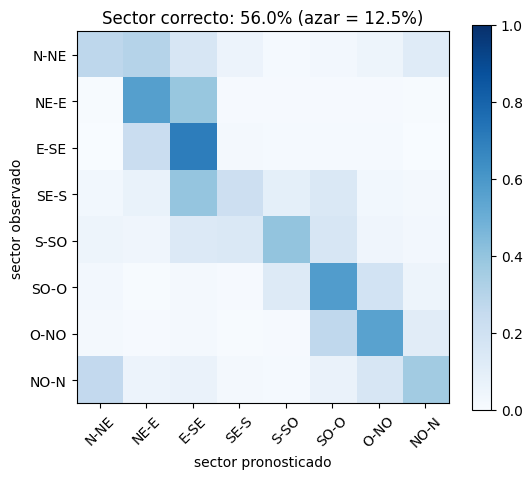

Detección del LEVANTE: recall 94.6%  precisión 93.4%  recall con viento fuerte 99.6%

CONCLUSIÓN: HARMONIE acierta el régimen (levante/poniente) aunque no la
dirección exacta. La dirección observada es REDUNDANTE frente a H_dir_sin/cos,
que ya están en el conjunto B — de ahí que E/F/G no aporten.
DECISIÓN: conjunto elegido para modelado = B (no cambia con este resultado;
lo que cambia es la explicación: HARMONIE reproduce el régimen del Estrecho pero
subestima la intensidad del levante en ~3.5 m/s, y el modelo corrige ese sesgo
condicionado al régimen.)


In [17]:
bins, etq = np.arange(0, 361, 45), ['N-NE','NE-E','E-SE','SE-S','S-SO','SO-O','O-NO','NO-N']
dd['sec_obs'] = pd.cut(dd.obs_dir, bins=bins, labels=etq, right=False)
dd['sec_har'] = pd.cut(dd.H_dir,  bins=bins, labels=etq, right=False)
acierto = (dd.sec_obs == dd.sec_har).mean()

lev_obs, lev_har = dd.sec_obs.isin(['NE-E','E-SE']), dd.sec_har.isin(['NE-E','E-SE'])
vp, fn = int((lev_obs & lev_har).sum()), int((lev_obs & ~lev_har).sum())
fp = int((~lev_obs & lev_har).sum())
recall, precision = 100*vp/(vp+fn), 100*vp/(vp+fp)
f_obs = lev_obs & (dd[OBJ] >= UMBRAL_ACTIVACION)
recall_fuerte = 100*(f_obs & lev_har).sum()/f_obs.sum() if f_obs.sum() else np.nan

fig, ax = plt.subplots(figsize=(6, 5))
conf = pd.crosstab(dd.sec_obs, dd.sec_har, normalize='index')
im = ax.imshow(conf, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(etq))); ax.set_xticklabels(etq, rotation=45)
ax.set_yticks(range(len(etq))); ax.set_yticklabels(etq)
ax.set_xlabel('sector pronosticado'); ax.set_ylabel('sector observado')
ax.set_title(f'Sector correcto: {100*acierto:.1f}% (azar = 12.5%)')
plt.colorbar(im)
plt.show()

print(f'Detección del LEVANTE: recall {recall:.1f}%  precisión {precision:.1f}%  '
      f'recall con viento fuerte {recall_fuerte:.1f}%')

print()
if dd.err_dir_abs.mean() < 40 and acierto > 0.45:
    print('CONCLUSIÓN: HARMONIE acierta el régimen (levante/poniente) aunque no la')
    print('dirección exacta. La dirección observada es REDUNDANTE frente a H_dir_sin/cos,')
    print('que ya están en el conjunto B — de ahí que E/F/G no aporten.')
else:
    print('CONCLUSIÓN: HARMONIE NO acierta bien la dirección; E/F/G fallan por otra razón')
    print('(probablemente la dirección observada en t-H ya no predice la de t a este horizonte).')
print('DECISIÓN: conjunto elegido para modelado =', ELEGIDO, '(no cambia con este resultado;')
print('lo que cambia es la explicación: HARMONIE reproduce el régimen del Estrecho pero')
print('subestima la intensidad del levante en ~3.5 m/s, y el modelo corrige ese sesgo')
print('condicionado al régimen.)')

---
## Resumen para la memoria

| Decisión | Valor | Justificación |
|---|---|---|
| Variables de HARMONIE | 14 de 19 conservadas | varianza nula / cuantización / redundancia con nulos |
| Codificación categórica | ninguna (seno/coseno) | no hay variables categóricas; hora/día/dirección son cíclicas |
| Tramo para SARIMA | el más largo | continuidad requerida por ACF/PACF/ADF/KPSS |
| Selección de pasada | `lead >= H + 4` | evita usar pronósticos emitidos después del instante de decisión |
| Horizonte máximo evaluable | 44 h | alcance de HARMONIE (48h) − latencia (4h) |
| Conjunto de features | el mejor entre A-G, por evidencia | el bloque atmosférico y la dirección observada no superan el ruido entre folds |
| `H_disp` | se conserva | no mejora el MAE, pero sirve de detector de incertidumbre (Human-in-the-loop) |
| Dirección observada | descartada como predictor | redundante: HARMONIE ya acierta el régimen |

**Advertencia metodológica.** Los MAE de distintos horizontes se calculan sobre
**muestras distintas** (el dataset encoge al exigir mayor `lead_min`); las
comparaciones entre horizontes son indicativas, no estrictas.

**Ficheros generados:**

| Fichero | Consumido por |
|---|---|
| `dataset_modelado.csv` | notebooks 3, 4, 5 (modelado) |
| `features_elegidas.json` | referencia del conjunto de variables elegido |
| `horizontes_validos.json` | referencia de la regla `lead_min = H + latencia` |

**Siguiente notebook:** 3 — Baselines estadísticos (persistencia, SARIMA, SARIMAX).

In [18]:
print(f'MAE de HARMONIE bruto a batir : {df.H_error.abs().mean():.3f} m/s')
print(f'Sesgo de HARMONIE              : {df.H_error.mean():+.3f} m/s')
print(f'Conjunto de features elegido   : {ELEGIDO} ({motivo})')

MAE de HARMONIE bruto a batir : 2.563 m/s
Sesgo de HARMONIE              : -2.127 m/s
Conjunto de features elegido   : B (ninguna ampliación sobre B supera el umbral del 1.0% de forma consistente entre particiones; se conserva B. Mejores MAE medios: E (+0.88%), F (+0.86%), G (+0.57%))
